<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab10/mldl_lab_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Train a convolutional autoencoder for image denoising using a small image dataset, adding noise to the images, defining, compiling and training the model, evaluating and visualizing the denoising results, and finally summarizing the findings and discussing potential next steps.

## Load and Prepare Dataset

### Subtask:
Load a small image dataset (e.g., MNIST) and preprocess it for training, including normalization and reshaping.


**Reasoning**:
First, I will import the necessary library for loading the dataset. Then, I will load the MNIST dataset, normalize the pixel values to a range of 0-1, and reshape the images to include a channel dimension, as specified in the instructions. Finally, I will store the preprocessed images in the required variables.



In [1]:
import tensorflow as tf

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Original training images shape: {x_train.shape}")
print(f"Original test images shape: {x_test.shape}")

# 2. Normalize the image data
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"Normalized training images min: {x_train_normalized.min()}, max: {x_train_normalized.max()}")
print(f"Normalized test images min: {x_test_normalized.min()}, max: {x_test_normalized.max()}")

# 3. Reshape the image data to include a channel dimension
x_train_processed = x_train_normalized[..., tf.newaxis]
x_test_processed = x_test_normalized[..., tf.newaxis]

# 4. Store the preprocessed training images in a variable named x_train_processed and the preprocessed test images in x_test_processed.
# (Already done in the previous step, variable names match)

print(f"Processed training images shape: {x_train_processed.shape}")
print(f"Processed test images shape: {x_test_processed.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training images shape: (60000, 28, 28)
Original test images shape: (10000, 28, 28)
Normalized training images min: 0.0, max: 1.0
Normalized test images min: 0.0, max: 1.0
Processed training images shape: (60000, 28, 28, 1)
Processed test images shape: (10000, 28, 28, 1)


## Add Noise to Images

### Subtask:
Introduce a form of noise (e.g., Gaussian noise) to the dataset to create noisy versions of the images. These noisy images will serve as input to the autoencoder.


**Reasoning**:
I need to define a function to add Gaussian noise to image arrays, apply this function to the preprocessed training and test datasets, and then store the results in `x_train_noisy` and `x_test_noisy` respectively, ensuring the pixel values are clipped to the valid range.



In [2]:
import numpy as np

# 1. Define a function to add Gaussian noise
def add_gaussian_noise(images, noise_factor=0.2):
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = images + noise
    noisy_images = np.clip(noisy_images, 0.0, 1.0)
    return noisy_images

# Define the noise factor
noise_factor = 0.2

# 2. Apply noise to x_train_processed
x_train_noisy = add_gaussian_noise(x_train_processed, noise_factor)

# 3. Apply noise to x_test_processed
x_test_noisy = add_gaussian_noise(x_test_processed, noise_factor)

print(f"Shape of x_train_noisy: {x_train_noisy.shape}")
print(f"Min value of x_train_noisy: {x_train_noisy.min()}, Max value of x_train_noisy: {x_train_noisy.max()}")
print(f"Shape of x_test_noisy: {x_test_noisy.shape}")
print(f"Min value of x_test_noisy: {x_test_noisy.min()}, Max value of x_test_noisy: {x_test_noisy.max()}")

Shape of x_train_noisy: (60000, 28, 28, 1)
Min value of x_train_noisy: 0.0, Max value of x_train_noisy: 1.0
Shape of x_test_noisy: (10000, 28, 28, 1)
Min value of x_test_noisy: 0.0, Max value of x_test_noisy: 1.0


## Define Autoencoder Model

### Subtask:
Define a simple convolutional autoencoder model architecture suitable for image denoising. This will include an encoder part to reduce dimensionality and a decoder part to reconstruct the image.


**Reasoning**:
To define the convolutional autoencoder model, I will import the necessary Keras layers, then construct the encoder and decoder components as specified, and finally create the full autoencoder model.



In [4]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras import Model

# Input shape of the images (e.g., MNIST images are 28x28 with 1 channel)
input_shape = x_train_processed.shape[1:]

# 1. Input layer
input_img = Input(shape=input_shape)

# 2. Encoder part
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# 3. Decoder part
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# 4. Autoencoder model
autoencoder = Model(input_img, decoded)

# Print the model summary to verify the architecture
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The autoencoder model has been defined. Now, I need to compile it by specifying an optimizer and a loss function before training. The Adam optimizer is a good general-purpose choice, and 'binary_crossentropy' is suitable for image data normalized to 0-1, as it treats each pixel as an independent binary classification.



In [5]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
print("Autoencoder model compiled successfully.")

Autoencoder model compiled successfully.


# Task
Train the autoencoder model using `x_train_noisy` as input and `x_train_processed` as the target. Use `x_test_noisy` and `x_test_processed` for validation data. Specify appropriate epochs and batch size (e.g., 10 epochs, batch size 128) and store the training history.

## Train Autoencoder Model

### Subtask:
Train the autoencoder model using `x_train_noisy` as input and `x_train_processed` as the target. Use `x_test_noisy` and `x_test_processed` for validation data. Specify appropriate epochs and batch size (e.g., 10 epochs, batch size 128) and store the training history.


**Reasoning**:
I need to train the autoencoder model using the specified training and validation datasets, epochs, and batch size, and store the training history in a variable named `history`.



In [6]:
history = autoencoder.fit(
    x_train_noisy,
    x_train_processed,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_processed)
)

print("Autoencoder model training complete. Training history stored in 'history' variable.")

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 227ms/step - loss: 0.1233 - val_loss: 0.0816
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 245ms/step - loss: 0.0793 - val_loss: 0.0767
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 249ms/step - loss: 0.0764 - val_loss: 0.0750
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 240ms/step - loss: 0.0749 - val_loss: 0.0737
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 218ms/step - loss: 0.0740 - val_loss: 0.0730
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 244ms/step - loss: 0.0733 - val_loss: 0.0724
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 246ms/step - loss: 0.0727 - val_loss: 0.0721
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 244ms/step - loss: 0.0723 - val_loss: 0.0717
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 246ms/step - loss: 0.0720 - val_loss: 0.0713
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 251ms/step - loss: 0.0717 - val_loss: 0.0714
Autoencoder model training complete. Training history stored in 'history' variable.


# Task
Evaluate the denoising performance of the trained autoencoder by predicting denoised images from `x_test_noisy`. Then, visualize a selection of original clean images (`x_test_processed`), their noisy counterparts (`x_test_noisy`), and the denoised outputs. Arrange them side-by-side with clear labels for comparison. After visualization, summarize the key findings from the training, evaluation, and visualization, and discuss potential next steps or improvements for the denoising autoencoder, such as trying different noise factors, model architectures, or datasets.

## Evaluate and Visualize Denoising Results

### Subtask:
Use the trained autoencoder to predict denoised images from `x_test_noisy`. Then, visualize a selection of original clean images (`x_test_processed`), their noisy counterparts (`x_test_noisy`), and the denoised outputs. Arrange them side-by-side for easy comparison and include clear labels.


**Reasoning**:
The first step is to use the trained `autoencoder` model to predict the denoised images from `x_test_noisy` and store them in `decoded_imgs` as per the instructions.



In [7]:
decoded_imgs = autoencoder.predict(x_test_noisy)
print("Denoised images predicted and stored in 'decoded_imgs'.")
print(f"Shape of decoded_imgs: {decoded_imgs.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Denoised images predicted and stored in 'decoded_imgs'.
Shape of decoded_imgs: (10000, 28, 28, 1)


**Reasoning**:
Now that the denoised images have been predicted, I will import `matplotlib` and visualize a selection of original, noisy, and denoised images side-by-side with clear labels, as instructed by the subtask.



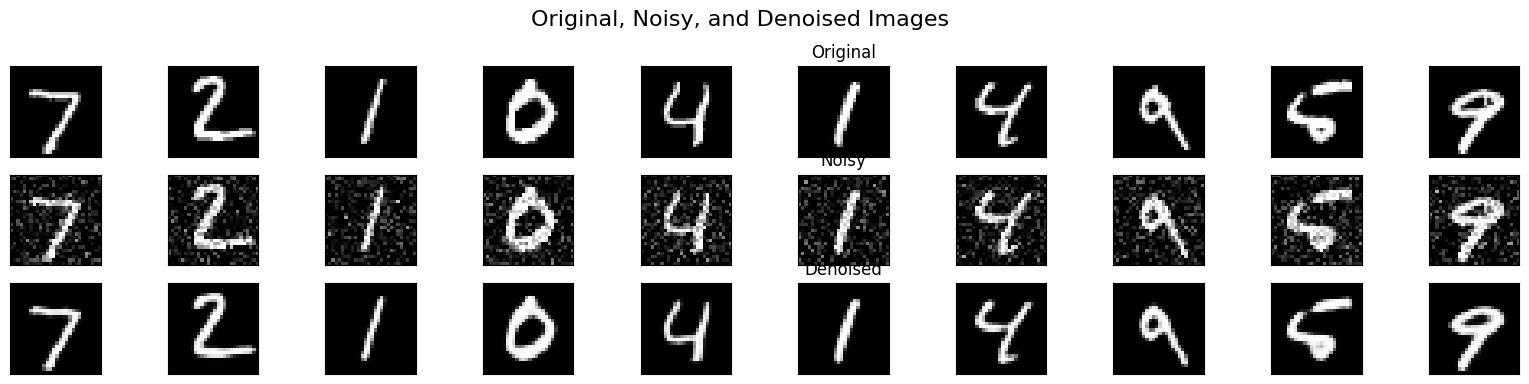

In [8]:
import matplotlib.pyplot as plt

# 3. Choose a few (e.g., 5-10) image indices to visualize from the test set.
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Display Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_processed[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Original')

    # Display Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Noisy')

    # Display Denoised Image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Denoised')

plt.suptitle('Original, Noisy, and Denoised Images', y=1.02, fontsize=16)
plt.show()